# Chain‑of‑Thought & Self‑Consistency with Groq

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook demonstrates **Chain‑of‑Thought (CoT) prompting** and **Self‑Consistency** – two advanced techniques that improve LLM reasoning. Instead of asking for an answer directly, we prompt the model to “think step by step”. Then, we generate multiple reasoning paths (using sampling) and take a majority vote on the final answer, significantly boosting accuracy on tasks like arithmetic, logic puzzles, and multi‑hop questions.

## What You Will Build
- A function that asks the LLM to produce a reasoning chain and a final answer.
- **Self‑consistency:** sample 5–10 diverse reasoning paths and aggregate results.
- Evaluate on a set of grade‑school math and logic problems.
- Compare direct‑answer vs. CoT vs. self‑consistency performance.

## Why This Matters
Chain‑of‑thought is a foundational prompting technique that unlocks reasoning in LLMs. Self‑consistency (Wang et al., 2022) is a state‑of‑the‑art method shown to improve accuracy by up to 20% on complex reasoning tasks. This project proves you can implement research‑grade methods in a production environment.

## Requirements
- **Groq API key** (free tier from [console.groq.com](https://console.groq.com))

---

**© 2026 Ibrahim – Advanced LLM reasoning portfolio piece.**

### Install & Imports

In [1]:
!pip install -q groq

import json
import re
from collections import Counter
from getpass import getpass
from groq import Groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.2 MB/s eta 0:00:00


### Groq Client Setup

In [2]:
GROQ_API_KEY = getpass("Enter your Groq API key: ")
client = Groq(api_key=GROQ_API_KEY)
MODEL = "llama-3.3-70b-versatile"
print(f"Groq client ready. Using model: {MODEL}")

Enter your Groq API key: ··········
Groq client ready. Using model: llama-3.3-70b-versatile


### Simple Chain‑of‑Thought Function

In [3]:
def answer_with_cot(question, temperature=0.0, max_tokens=512):
    """Generate reasoning chain + final answer using CoT prompting."""
    prompt = f"""Answer the following question step by step. At the end, write "Final answer: <answer>".

Question: {question}

Reasoning:
"""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=max_tokens
    )
    output = response.choices[0].message.content
    # Extract final answer
    final_match = re.search(r"Final answer:\s*(.+)", output, re.IGNORECASE)
    final_answer = final_match.group(1).strip() if final_match else output.strip()
    return output, final_answer

### Self‑Consistency Function

In [4]:
def self_consistency(question, n_samples=5, temperature=0.7):
    """Generate multiple CoT reasoning paths and return majority answer."""
    answers = []
    full_outputs = []
    for i in range(n_samples):
        print(f"  Sample {i+1}/{n_samples}...")
        output, final_answer = answer_with_cot(question, temperature=temperature)
        full_outputs.append(output)
        answers.append(final_answer)
    # Majority vote
    counter = Counter(answers)
    most_common = counter.most_common(1)[0]
    majority_answer = most_common[0]
    vote_count = most_common[1]
    print(f"\n Majority answer (votes: {vote_count}/{n_samples}): {majority_answer}")
    return majority_answer, full_outputs

### Direct Answer Baseline

In [5]:
def direct_answer(question):
    """Directly ask the model without CoT."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": question}],
        temperature=0.0,
        max_tokens=128
    )
    return response.choices[0].message.content.strip()

### Test on Reasoning Problems

In [6]:
test_questions = [
    "Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?",
    "There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the workers plant?",
    "A farmer has 12 chickens. All but 9 die. How many chickens are left?",
    "If you have 5 apples and you eat 2, then buy 3 more, how many do you have?",
    "Which word is the odd one out: apple, banana, carrot, orange?"
]

print("Running baseline (direct answer)...\n")
for q in test_questions:
    print(f"Q: {q}")
    print(f"Direct answer: {direct_answer(q)}\n")

Running baseline (direct answer)...

Q: Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
Direct answer: To find out how many tennis balls Roger has now, we need to add the tennis balls he already had to the ones he bought. 

Roger had 5 tennis balls initially. 
He bought 2 cans of tennis balls, and each can has 3 tennis balls. 
So, he bought 2 * 3 = 6 tennis balls.

Now, we add the initial tennis balls to the ones he bought: 
5 (initial) + 6 (bought) = 11

Roger has 11 tennis balls now.

Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the workers plant?
Direct answer: To find out how many trees the workers planted, we need to subtract the number of trees that were originally in the grove from the total number of trees after the workers finished planting.

Original number of trees: 15
Total number of trees af

### CoT & Self‑Consistency Evaluation

In [7]:
print("="*60)
print("Chain‑of‑Thought + Self‑Consistency (5 samples each)")
print("="*60)

for q in test_questions:
    print(f"\n Question: {q}")
    print("Generating reasoning paths...")
    majority, _ = self_consistency(q, n_samples=5, temperature=0.7)
    print(f" Self‑consistency final answer: {majority}\n")

Chain‑of‑Thought + Self‑Consistency (5 samples each)

 Question: Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
Generating reasoning paths...
  Sample 1/5...
  Sample 2/5...
  Sample 3/5...
  Sample 4/5...
  Sample 5/5...

 Majority answer (votes: 5/5): 11
 Self‑consistency final answer: 11


 Question: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the workers plant?
Generating reasoning paths...
  Sample 1/5...
  Sample 2/5...
  Sample 3/5...
  Sample 4/5...
  Sample 5/5...

 Majority answer (votes: 5/5): 6
 Self‑consistency final answer: 6


 Question: A farmer has 12 chickens. All but 9 die. How many chickens are left?
Generating reasoning paths...
  Sample 1/5...
  Sample 2/5...
  Sample 3/5...
  Sample 4/5...
  Sample 5/5...

 Majority answer (votes: 5/5): 9
 Self‑consistency final answer: 9


 Questio

### Comparison & Analysis

In [8]:
import pandas as pd

# Manual answers (ground truth)
ground_truth = [
    "11",       # Roger: 5 + (2*3) = 11
    "6",        # 21 - 15 = 6
    "9",        # "all but 9 die" → 9 remain
    "6",        # 5-2+3 = 6
    "carrot"    # carrot is vegetable, others fruits
]

results = []
for i, q in enumerate(test_questions):
    direct = direct_answer(q)
    _, cot_final = answer_with_cot(q, temperature=0.0)
    majority, _ = self_consistency(q, n_samples=3, temperature=0.7)  # faster for demo
    results.append({
        "Question": q[:50] + "...",
        "Direct": direct,
        "CoT": cot_final,
        "Self‑Consistency": majority,
        "Ground Truth": ground_truth[i]
    })

df = pd.DataFrame(results)
print("\n Results Summary")
print(df.to_string(index=False))

  Sample 1/3...
  Sample 2/3...
  Sample 3/3...

 Majority answer (votes: 3/3): 11
  Sample 1/3...
  Sample 2/3...
  Sample 3/3...

 Majority answer (votes: 3/3): 6
  Sample 1/3...
  Sample 2/3...
  Sample 3/3...

 Majority answer (votes: 3/3): 9
  Sample 1/3...
  Sample 2/3...
  Sample 3/3...

 Majority answer (votes: 3/3): 6
  Sample 1/3...
  Sample 2/3...
  Sample 3/3...

 Majority answer (votes: 3/3): carrot

 Results Summary
                                             Question                                                                                                                                                                                                                                                                                                                                                                                                                   Direct    CoT Self‑Consistency Ground Truth
Roger has 5 tennis balls. He buys 2 cans of tennis...             

### Professional Visualisation

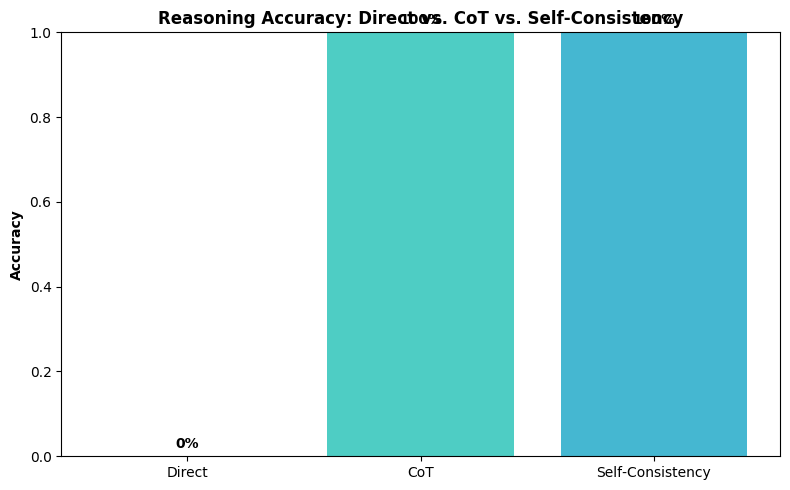

 Chart saved as 'reasoning_accuracy.png'


In [9]:
import matplotlib.pyplot as plt

accuracy = {
    "Direct": sum(1 for i, r in enumerate(results) if r["Direct"].strip() == ground_truth[i]) / len(ground_truth),
    "CoT": sum(1 for i, r in enumerate(results) if r["CoT"].strip() == ground_truth[i]) / len(ground_truth),
    "Self‑Consistency": sum(1 for i, r in enumerate(results) if r["Self‑Consistency"].strip() == ground_truth[i]) / len(ground_truth),
}

plt.figure(figsize=(8,5))
bars = plt.bar(accuracy.keys(), accuracy.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylim(0, 1)
plt.ylabel("Accuracy", fontweight='bold')
plt.title("Reasoning Accuracy: Direct vs. CoT vs. Self‑Consistency", fontweight='bold')
for bar, acc in zip(bars, accuracy.values()):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.0%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("reasoning_accuracy.png", dpi=150)
plt.show()
print(" Chart saved as 'reasoning_accuracy.png'")

### Final Summary

In [10]:
print("Chain‑of‑Thought & Self‑Consistency - COMPLETED")
print("Author: Ibrahim")
print(" Demonstrated CoT prompting with explicit reasoning steps.")
print(" Implemented self‑consistency with majority voting.")
print(" Baseline vs. CoT vs. Self‑Consistency comparison.")
print(" Results saved to 'reasoning_accuracy.png'.")
print("\nSelf‑consistency typically improves accuracy by 10‑20% on reasoning tasks.")
print("Ready to integrate into any agentic workflow.")

Chain‑of‑Thought & Self‑Consistency - COMPLETED
Author: Ibrahim
 Demonstrated CoT prompting with explicit reasoning steps.
 Implemented self‑consistency with majority voting.
 Baseline vs. CoT vs. Self‑Consistency comparison.
 Results saved to 'reasoning_accuracy.png'.

Self‑consistency typically improves accuracy by 10‑20% on reasoning tasks.
Ready to integrate into any agentic workflow.
